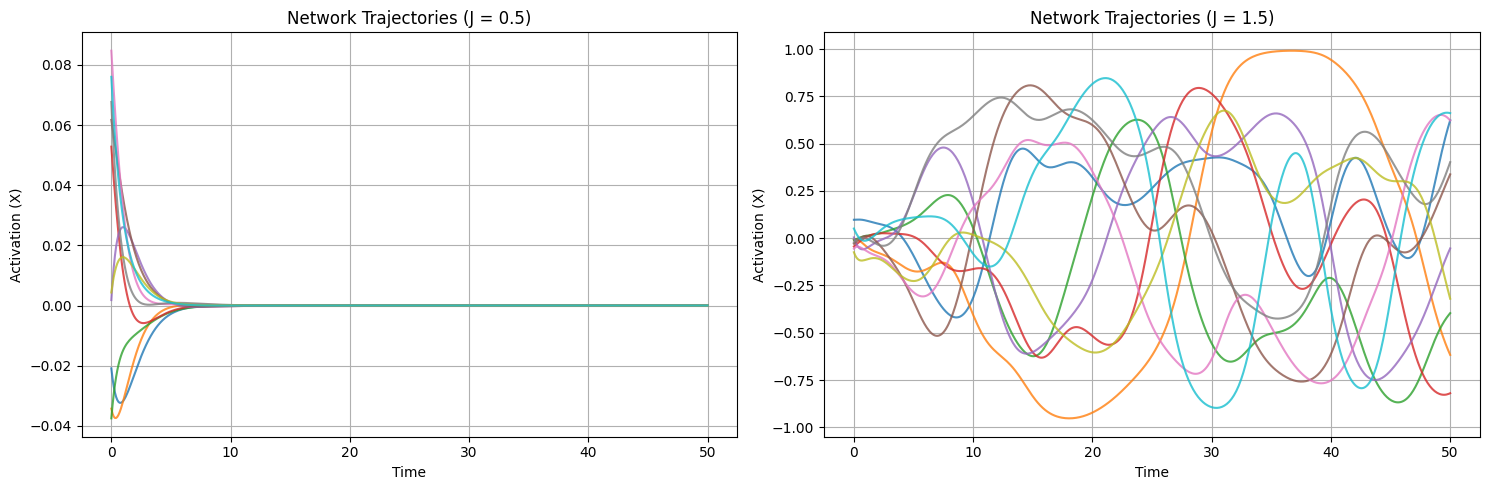

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Initialization Functions ---
def init_weights(N, J, mean=0.0):
    """
    Initializes the W matrix from a Gaussian distribution.
    The variance is J^2 / N, so the standard deviation is J / sqrt(N).
    """
    std_dev = J / np.sqrt(N)
    W = np.random.normal(loc=mean, scale=std_dev, size=(N, N))
    return W

def init_activations(N, low=-0.1, high=0.1):
    """
    Initializes the X vector (the starting activations of our neurons).
    We give them a small random starting bump between `low` and `high`.
    """
    X = np.random.uniform(low, high, size=N)
    return X

# --- 2. The Main Simulation Function ---
def simulate_network(N, J, t_max, dt, mean=0.0):
    """
    Simulates the network over time `t_max`.
    Returns a matrix where each row represents time (t), 
    and columns represent the activation of each neuron.
    """
    n_steps = int(t_max / dt)
    
    # 1. Initialize our W matrix and X vector
    W = init_weights(N, J, mean)
    X = init_activations(N)
    
    # 2. Create the empty history matrix (Rows = Time, Columns = Neurons)
    history = np.zeros((n_steps, N))
    history[0] = X
    
    # 3. Simulate forward in time using Euler method
    for t in range(1, n_steps):
        # Calculate the incoming signals (W * X)
        inputs = np.dot(W, X)
        
        # Calculate the change (dX/dt) based on the differential equation
        dX_dt = -X + np.tanh(inputs)
        
        # Update X: New X = Old X + (Change * delta time)
        X = X + dX_dt * dt
        
        # Store the new X row in our history matrix
        history[t] = X
        
    return history


# --- Plotting Function ---
def plot_trajectories(time_axis, history_list, titles, num_neurons=10):
    """
    Takes a list of history matrices and plots their trajectories side-by-side.
    """
    fig, axes = plt.subplots(1, len(history_list), figsize=(15, 5))
    
    for i, history in enumerate(history_list):
        axes[i].plot(time_axis, history[:, :num_neurons], alpha=0.8)
        axes[i].set_title(titles[i])
        axes[i].set_xlabel("Time")
        axes[i].set_ylabel("Activation (X)")
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

# --- Execution ---
# Run experiments
history_decay = simulate_network(N=500, J=0.5, t_max=50, dt=0.1)
history_chaos = simulate_network(N=500, J=1.5, t_max=50, dt=0.1)

# Plot using our new function!
time_axis = np.linspace(0, 50, int(50 / 0.1))
plot_trajectories(
    time_axis=time_axis,
    history_list=[history_decay, history_chaos],
    titles=["Network Trajectories (J = 0.5)", "Network Trajectories (J = 1.5)"]
)



Gaussian random network

The activity traces in this figure show the transition from a stable resting state to chaotic dynamics in the fully connected Gaussian network. In this model, the recurrent weights are sampled independently from a zero-mean Gaussian distribution with variance ( \mathrm{Var}(W_{ij}) = \frac{J^2}{N} ). For small (J), the trajectories decay back to zero after the initial perturbation, meaning that the resting state ( \vec{r} \approx \vec{0} ) is stable and the network cannot sustain activity on its own. For larger (J), the activity no longer returns to zero and instead continues to fluctuate irregularly over time, indicating the onset of a chaotic regime with persistent internally generated dynamics.

This transition can be understood by linearizing the dynamics near the resting state. Starting from

[
\frac{d\vec{r}}{dt} = -\vec{r} + \tanh(W\vec{r}),
]

and using the approximation ( \tanh(x) \approx x ) for small (x), we obtain

[
\frac{d\vec{r}}{dt} \approx -\vec{r} + W\vec{r} = (W-I)\vec{r}.
]

The stability of the resting state is therefore determined by the eigenvalues of (W-I). For a large random Gaussian matrix, the eigenvalues of (W) are distributed in a disk with spectral radius

[
\rho(W) = \sqrt{N,\mathrm{Var}(W_{ij})}.
]

Substituting ( \mathrm{Var}(W_{ij}) = \frac{J^2}{N} ) gives

[
\rho(W) = \sqrt{N\frac{J^2}{N}} = J.
]

The resting state loses stability when the spectral radius becomes larger than (1), so the critical condition is

[
\rho(W) > 1 ;\Rightarrow; J > 1.
]

This explains why the transition occurs at ( J_c = 1 ): below this threshold, activity decays to zero, whereas above it, the recurrent feedback is strong enough to maintain chaotic, self-sustained fluctuations.

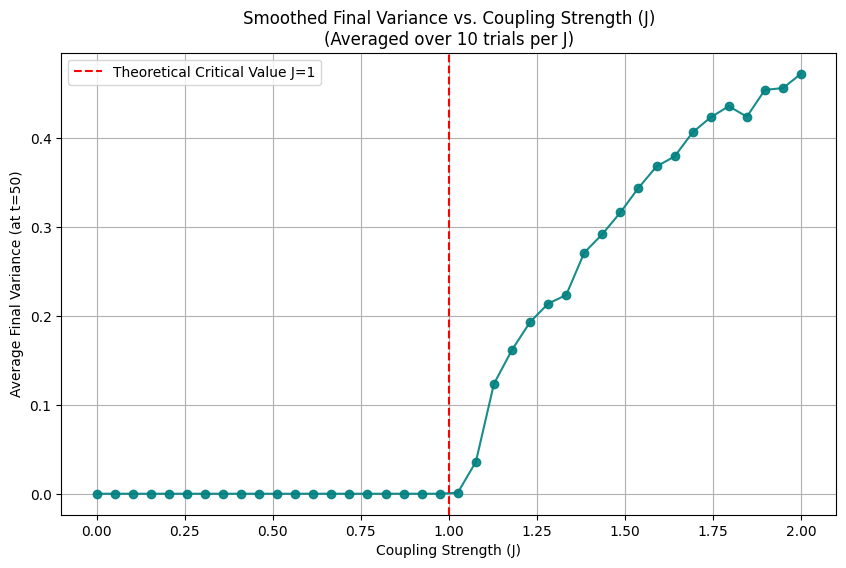

In [25]:
# --- Plotting Function ---
def plot_final_variance(J_values, variances, T, trials):
    """
    Plots the relationship between J and the final network variance.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(J_values, variances, marker='o', linestyle='-', color='teal', alpha=0.9)
    plt.axvline(x=1.0, color='red', linestyle='--', label='Theoretical Critical Value J=1')

    plt.title(f"Smoothed Final Variance vs. Coupling Strength (J)\n(Averaged over {trials} trials per J)")
    plt.xlabel("Coupling Strength (J)")
    plt.ylabel(f"Average Final Variance (at t={T})")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Execution ---
n = 40
T = 50
dt = 0.1
num_trials = 10
J_values = np.linspace(0, 2, n)
smoothed_variances = []

for J in J_values:
    trial_variances = []
    
    for trial in range(num_trials):
        # We reuse simulate_network here!
        history = simulate_network(N=500, J=J, t_max=T, dt=dt)
        trial_variances.append(np.var(history[-1]))
        
    smoothed_variances.append(np.mean(trial_variances))

# Plot using our new function!
plot_final_variance(J_values, smoothed_variances, T, num_trials)


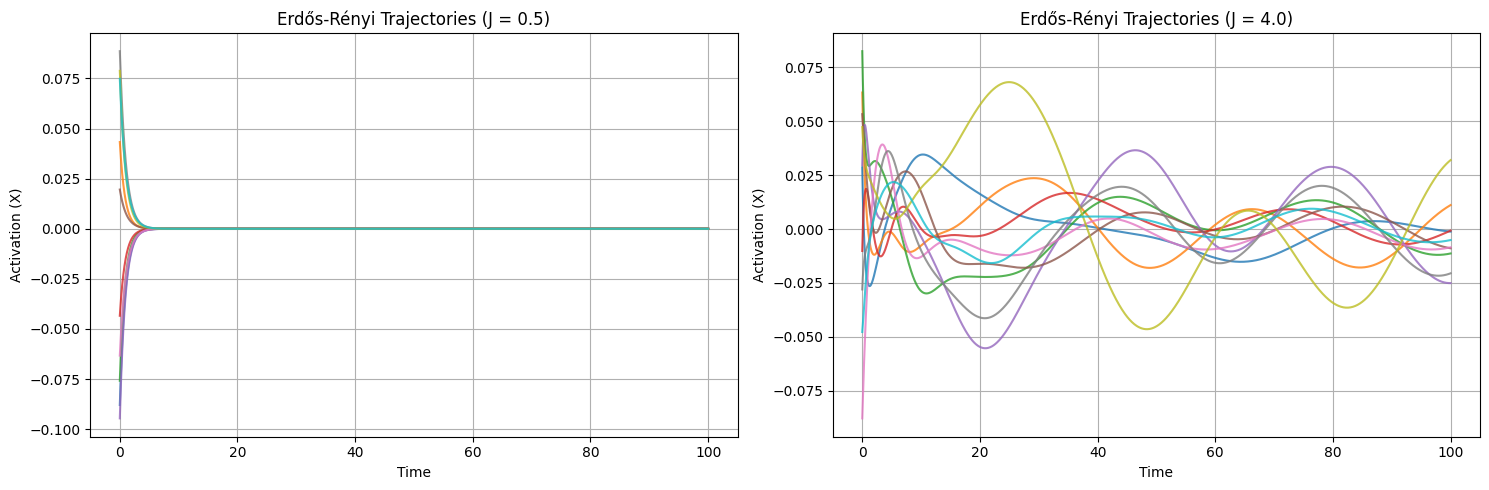

In [43]:
# --- 6. The Erdős-Rényi (ER) Network Simulation ---

def init_erdos_renyi_weights(N, p, J):
    """
    Creates an Erdős-Rényi network. Nodes connect with probability `p`.
    Connection strength is homogeneous: J / k (where k = p * N).
    We randomly make half the connections positive (excitatory) 
    and half negative (inhibitory) to prevent the network from flatlining.
    """
    k = p * N
    strength = J / k
    
    # 1. Roll the dice for every pair of neurons (values between 0 and 1)
    random_probs = np.random.rand(N, N)
    
    # 2. A connection exists (1.0) ONLY if the probability is less than p
    adjacency = (random_probs < p).astype(float)
    
    # 3. Randomly flip signs (half excitatory +1, half inhibitory -1)
    signs = np.random.choice([-1, 1], size=(N, N))
    
    # 4. Calculate Final Matrix W
    W = adjacency * signs * strength
    return W

def simulate_er_network(N, p, J, t_max, dt):
    """
    Identical to our previous simulation, but calls the ER initialization.
    """
    n_steps = int(t_max / dt)
    
    # Initialize ER matrix instead of Gaussian
    W = init_erdos_renyi_weights(N, p, J)
    X = init_activations(N) # Reusing our function from earlier!
    
    history = np.zeros((n_steps, N))
    history[0] = X
    
    for t in range(1, n_steps):
        inputs = np.dot(W, X)
        dX_dt = -X + np.tanh(inputs)
        X = X + dX_dt * dt
        history[t] = X
        
    return history

# --- Execution ---
N = 500
p = 0.1       # 10% connection probability (sparse!)
t_max = 100
dt = 0.1
time_axis = np.linspace(0, t_max, int(t_max / dt))

# NOTE: Because the math of the variance changes for ER networks, 
# you often need a slightly higher J to trigger chaos!
history_er_decay = simulate_er_network(N=N, p=p, J=0.5, t_max=t_max, dt=dt)
history_er_chaos = simulate_er_network(N=N, p=p, J=7, t_max=t_max, dt=dt)

# Reusing our sleek plotting function from earlier!
plot_trajectories(
    time_axis=time_axis,
    history_list=[history_er_decay, history_er_chaos],
    titles=["Erdős-Rényi Trajectories (J = 0.5)", "Erdős-Rényi Trajectories (J = 4.0)"]
)


In [46]:

\rho(W) = \sqrt{N\,\mathrm{Var}(W_{ij})}


SyntaxError: unexpected character after line continuation character (2822929492.py, line 1)